Day3

In [2]:
import cv2
import matplotlib.pyplot as plt 

(480, 512)


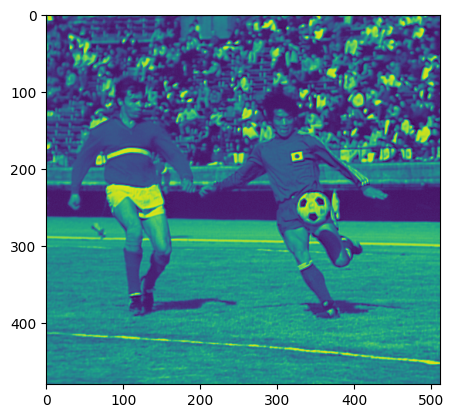

In [8]:
img=cv2.imread("soccer.bmp",0)
print(img.shape)
plt.imshow(img)

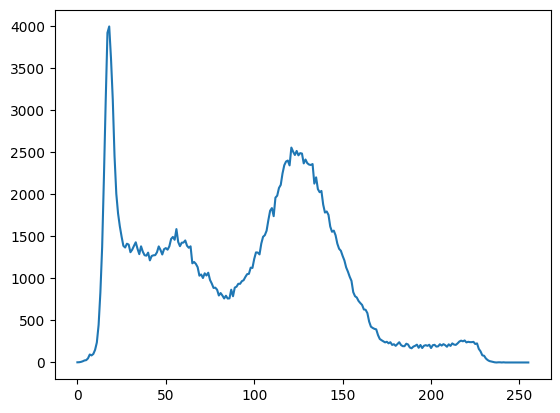

In [ ]:
hist=cv2.calcHist([img],[0],None,[256],[0,256])
plt.plot(hist)
plt.title("image histogram")
plt.show()

Histogram Equalization

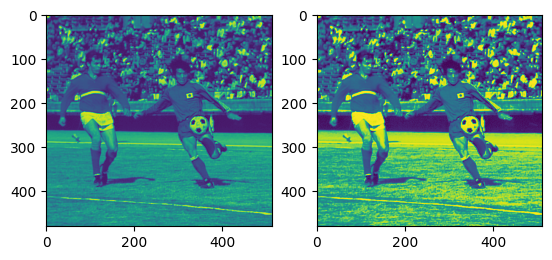

In [10]:
equalized=cv2.equalizeHist(img)
plt.subplot(121)
plt.imshow(img)
plt.subplot(122)
plt.imshow(equalized)
plt.show()

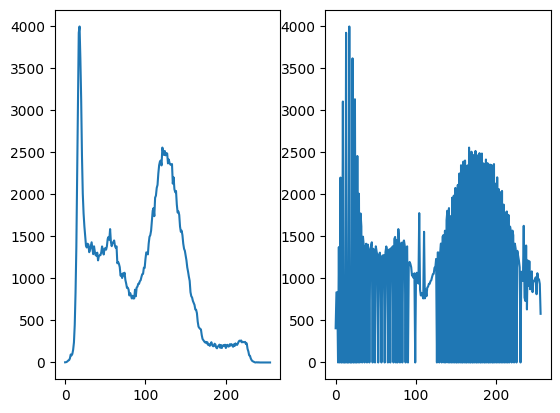

In [12]:
HistEqualised=cv2.calcHist([equalized],[0],None,[256],[0,256])
plt.subplot(121)
plt.plot(hist)
plt.subplot(122)
plt.plot(HistEqualised)
plt.show()

Contrast Limited Adaptive Histogram Equalization

Example where histogram equalization fails and clahe is used

In [4]:
img2=cv2.imread("histequalVSchlahe.jpg",0)
clahe=cv2.createCLAHE(clipLimit=2,tileGridSize=(8,8))
claheimg=clahe.apply(img2)
img2HistEqualized=cv2.equalizeHist(img2)


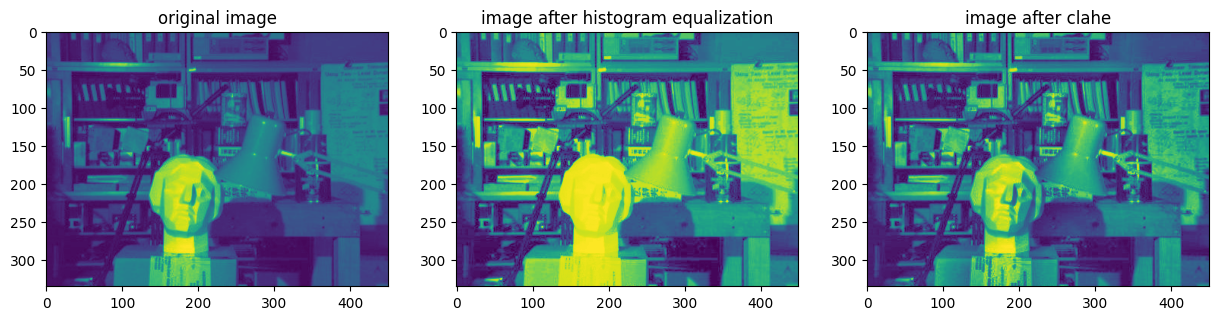

In [6]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img2)
plt.title("original image")

plt.subplot(132)
plt.imshow(img2HistEqualized)
plt.title("image after histogram equalization")

plt.subplot(133)
plt.imshow(claheimg)
plt.title("image after clahe")

plt.show()

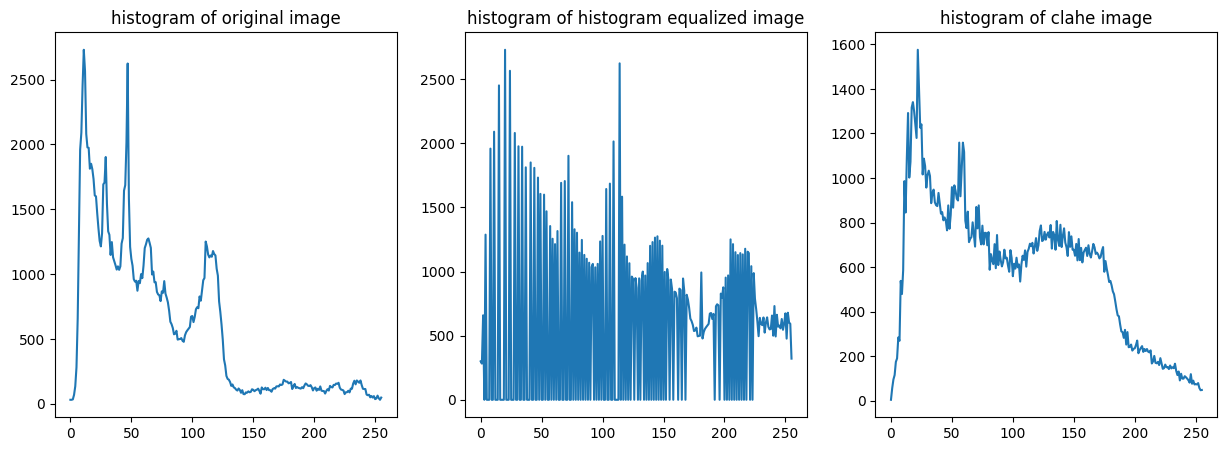

In [7]:
img2hist=cv2.calcHist([img2],[0],None,[256],[0,256])
img2afterEqualization=cv2.calcHist([img2HistEqualized],[0],None,[256],[0,256])
clahehist=cv2.calcHist([claheimg],[0],None,[256],[0,256])

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.plot(img2hist)
plt.title("histogram of original image")

plt.subplot(132)
plt.plot(img2afterEqualization)
plt.title("histogram of histogram equalized image")

plt.subplot(133)
plt.plot(clahehist)
plt.title("histogram of clahe image")
plt.show()

Day3 Summary

Images can have low contrast, i.e. pixel intensities can be concentrated at a particular region. To improve the contrast we use Histogram equalization technique. 
In this we firstly compute Histogram of the pixel intensities of the image.
Now we compute Cummulative distribution function for histogram.
We multiply CDF with max intesity value(for 8 bit image we multiply with 255) to get new CDF.
Using this new CDF we reconstruct the image.
The reconstructed image is histogram equalized.

Pros: We get better contrast image.
Cons: 
- it amplifies noise
- it changes original brigthness. If your image is a night scene, post histogram equalization its mean intensity would have increased
- images with good contrast may be over stretched unnecessarily.
- It performs poorly on images with multiples regions. Say there is dark forest and bright sky, after histogram equalization the forest continues to remains dark while the brigth sky gets saturated or washed out. Region based equalization is much better. 

Ro overcome these problems we use Contrast Limited Adaptive Histogram Equalization (CLAHE)

Syntax - cv2.createCLAHE(clipLimit=2,tileGridSize=(8,8))
There are two arguments,
clipLimit is used to restrict the number of pixels that should have a particular intensity to avoid sharp concentration at a particular color thus beating our purpose of contrast stretching
tileGridSize is used to divide the original picture into sub parts and apply equalization to each of these sub parts and stich them pack together and uses interpolation to blend two adjacent tiles.